# EMG TRIAL INITIATION SIMULATOR


In [12]:
# Phase 0: Imports and Constants
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets
from open_ephys.analysis import Session
from scipy.signal import butter, filtfilt, lfilter
import json
from pathlib import Path
from collections import defaultdict
import scipy.stats as stats
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

# Processing protocols
PROTOCOL_ONLINE = "Online Filtering"
PROTOCOL_OFFLINE = "Offline Filtering"
PROTOCOL_OPTIONS = [PROTOCOL_ONLINE, PROTOCOL_OFFLINE]
DEFAULT_PROTOCOL = PROTOCOL_OFFLINE

# Binning & trial constants (from Todo)
BIN_DURATION_MS = 50
SAMPLE_RATE_HINT = 5000  # default hint; overwritten by session metadata when available
BIN_SAMPLE_COUNT = int((SAMPLE_RATE_HINT / 1000) * BIN_DURATION_MS)

TRIAL_INIT_MIN_MS = 2200
TRIAL_INIT_MAX_MS = 2700
TRIAL_INIT_MIN_UV = 5.0
TRIAL_INIT_MAX_UV = 300.0

# Default directory
DEFAULT_DATA_DIR = os.getcwd()

print("Phase 0: imports and constants loaded. Default protocol:", DEFAULT_PROTOCOL)


Phase 0: imports and constants loaded. Default protocol: Offline Filtering


# 1. Selecting and Exploring a Recording Session

Open Ephys organizes experiments into “sessions,” each with one or more Record Nodes.
Here we select which node to analyze and define which session directory to load.

### Function: Scanning Experiment Structure

We’ll define a helper function to automatically list all experiments and recordings inside a session directory.

In [13]:
def scan_experiment_structure(session_dir, record_node_name="Record Node 106"):
    """
    Scans a given Open Ephys session directory and returns a dictionary of 
    experiment names and their associated recordings.
    """
    node_path = os.path.join(session_dir, record_node_name)
    
    if not os.path.exists(node_path):
        print(f"Record Node directory not found: {node_path}")
        return {}
    
    experiment_info = defaultdict(list)
    for item in sorted(os.listdir(node_path)):
        exp_path = os.path.join(node_path, item)
        if os.path.isdir(exp_path) and item.startswith("experiment"):
            recordings = [r for r in sorted(os.listdir(exp_path)) 
                          if os.path.isdir(os.path.join(exp_path, r)) and r.startswith("recording")]
            experiment_info[item] = recordings
    return experiment_info


# 2. Loading the Session Data

Now let’s point Python to a specific Open Ephys session directory and create a Session object.

In [14]:
# ==== Load Session ====
#directory = '1-21-2026/HRPilot-06_Test1_2026-01-21_10-53-20_001'
#directory = '1-21-2026/HRPilot-06_Test2_2026-01-21_19-59-58_003'
#directory = '1-21-2026/HRPilot-08_Test1_2026-01-21_11-48-40_002'
#directory = '1-21-2026/HRPilot-08_Test2_2026-01-21_20-22-57_004'
#directory = '1-21-2026/HRPilot-09_Test12026-01-21_18-17-01_001'
#directory = '1-21-2026/HRPilot-10_Test1_2026-01-21_17-30-13_001'
directory = '1-21-2026/HRPilot-10_Test2_2026-01-21_18-38-25_002'

#directory = 'HRPilot-05_FirstChronicTest1_2025-08-27_17-17-00_001'

session = Session(directory)
print('✅ Pass Initial Test, Moving on to Loading Session...\n')

✅ Pass Initial Test, Moving on to Loading Session...



### Scanning the Session's Structure

> Observe how the floating variable "w" we previously defined earlier is used here to 

In [15]:
record_node_name = "Record Node 106" if DEFAULT_PROTOCOL == PROTOCOL_ONLINE else "Record Node 111"
record_node_index = 0 if DEFAULT_PROTOCOL == PROTOCOL_ONLINE else 1
structure = scan_experiment_structure(directory, record_node_name)

# Flatten all experiment-recording pairs
flat_recordings = []
for exp_name, rec_list in structure.items():
    for rec in rec_list:
        flat_recordings.append((exp_name, rec))

print(f"Found {len(flat_recordings)} recordings across {len(structure)} experiments.")

''' # Flatten experiment/recording pairs
            flat = []
            for exp, recs in structure.items():
                for r in recs:
                    flat.append((exp, r))
            globals()['flat_recordings'] = flat
            print(f"Discovered {len(flat)} recordings (showing up to 20):", [f"{e}/{r}" for e,r in flat[:20]])
'''


Found 1 recordings across 1 experiments.


' # Flatten experiment/recording pairs\n            flat = []\n            for exp, recs in structure.items():\n                for r in recs:\n                    flat.append((exp, r))\n            globals()[\'flat_recordings\'] = flat\n            print(f"Discovered {len(flat)} recordings (showing up to 20):", [f"{e}/{r}" for e,r in flat[:20]])\n'

In [ ]:

# Phase 1: Recording selection and metadata loading
from ipywidgets import Button, Output, Dropdown

# Make options from flat_recordings if available
try:
    rec_options = [f"{i}: {e}/{r}" for i,(e,r) in enumerate(flat_recordings)]
except Exception:
    rec_options = []

recording_dropdown = Dropdown(options=rec_options, description='Recording:')
load_recording_button = Button(description='Open Recording', button_style='primary')
rec_output = Output()


def on_open_recording(b):
    with rec_output:
        clear_output()
        if not recording_dropdown.options:
            print("No recordings discovered. Use the 'Load Session' button in Phase 0 and select a record node.")
            return
        sel = recording_dropdown.value
        idx = int(str(sel).split(':',1)[0])
        try:
            # Try to fetch recording from Session object
            recording = session.recordnodes[record_node_index].recordings[idx]
            globals()['recording'] = recording
            print("Loaded recording:", recording)
            directory_str = recording.directory
            globals()['directory_str'] = directory_str

            parts = directory_str.split(os.sep)
            record_node_name = parts[-3]
            experiment_name  = parts[-2]
            recording_name   = parts[-1]
            globals()['record_node_name'] = record_node_name
            globals()['experiment_name'] = experiment_name
            globals()['recording_name'] = recording_name

            # Extract continuous data and metadata
            stream = recording.continuous[0]
            metadata = stream.metadata
            globals()['sample_rate'] = metadata.sample_rate
            globals()['num_channels'] = metadata.num_channels
            globals()['channel_names'] = metadata.channel_names

            print(f"Sample rate: {metadata.sample_rate} Hz | Channels: {metadata.num_channels} | Names: {metadata.channel_names}")

            # Update BIN_SAMPLE_COUNT based on actual sample_rate
            global BIN_SAMPLE_COUNT
            BIN_SAMPLE_COUNT = int((metadata.sample_rate / 1000) * BIN_DURATION_MS)
            print(f"BIN_SAMPLE_COUNT set to {BIN_SAMPLE_COUNT} samples")

            # Preload full data (be careful on large datasets)
            timestamps = stream.timestamps
            n_timestamps = timestamps.shape[0]
            data = stream.get_samples(start_sample_index=0, end_sample_index=n_timestamps)
            globals()['timestamps'] = timestamps
            globals()['data'] = data
            print("Data shape:", data.shape)

        except Exception as e:
            print("Error loading recording:", e)

load_recording_button.on_click(on_open_recording)

display(recording_dropdown, load_recording_button, rec_output)


Dropdown(description='Recording:', options=('0: experiment1/recording1',), value='0: experiment1/recording1')

Button(button_style='primary', description='Open Recording', style=ButtonStyle())

Output()

Applied offline bandpass (100.0-1000.0 Hz) using lfilter at 5000.0 Hz


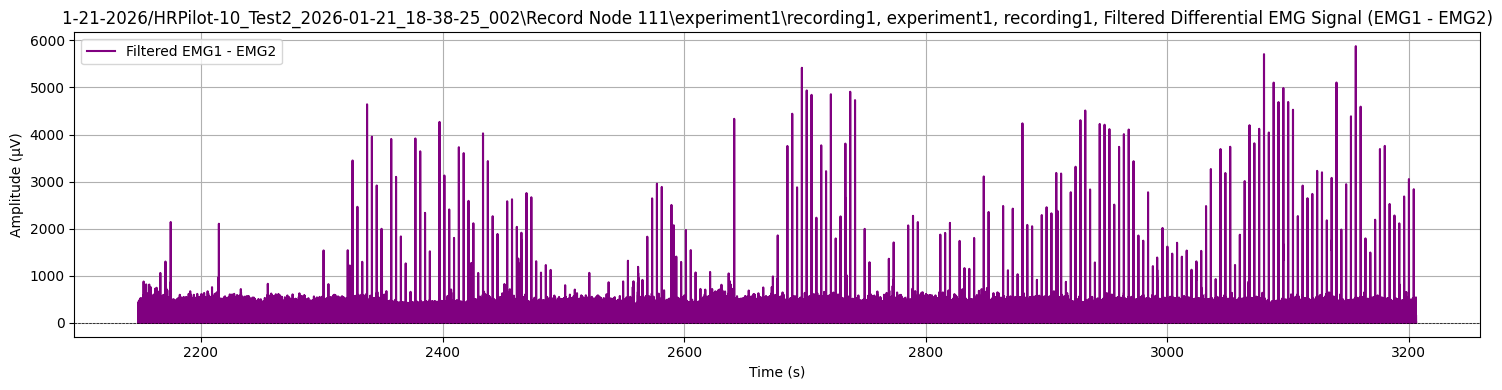

In [ ]:

# Phase 1: EMG processing and full-trace plotting (protocol-aware)
from scipy.signal import butter, filtfilt, lfilter

try:
    timestamps
    data
except NameError:
    print("No recording data loaded. Please open a recording first.")
else:
    protocol = DEFAULT_PROTOCOL


    if record_node_name == "Record Node 106": #protocol == PROTOCOL_ONLINE:
        # If online filtered, the data might already be filtered on channel 3
        differential_filt = data[:, 3]
        print("Using Online Filtering: assuming channel 3 is prefiltered differential EMG")
    else:
        # Offline filtering: compute diff then apply bandpass
        
        # ==== EMG Processing ====
        emg1_raw = data[:, 2]
        emg2_raw = data[:, 3]
        differential = (emg2_raw - emg1_raw)
        lowcut = 100.0
        highcut = 1000.0
        sample_rate = globals().get('sample_rate', SAMPLE_RATE_HINT)
        b, a = butter(2, np.array([lowcut, highcut])/(sample_rate/2), btype='bandpass')
        # Use filtfilt for zero-phase filtering
        differential_filt = lfilter(b, a, differential)
        print(f"Applied offline bandpass ({lowcut}-{highcut} Hz) using lfilter at {sample_rate} Hz")

    differential_abs = np.abs(differential_filt)
    differential_emg = differential_abs

    plt.figure(figsize=(15, 4))
    plt.plot(timestamps, differential_emg, label="Filtered EMG1 - EMG2", color='purple')
    plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
    plt.title(f"{directory_str}, {experiment_name}, {recording_name}, Filtered Differential EMG Signal (EMG1 - EMG2)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (μV)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [18]:
# Phase 1: Segment navigation UI (view long recordings in short windows)
segment_duration = 10  # seconds
try:
    total_time = timestamps[-1] - timestamps[0]
    num_segments = int(np.ceil(total_time / segment_duration))
    current_segment = 0

    from ipywidgets import Button, VBox
    output_segment = Output()

    def plot_segment(segment_idx):
        start_time = timestamps[0] + segment_idx * segment_duration
        end_time = min(start_time + segment_duration, timestamps[-1])
        mask = (timestamps >= start_time) & (timestamps < end_time)
        plt.figure(figsize=(15, 4))
        plt.plot(timestamps[mask] - start_time, differential_emg[mask], label="Filtered EMG", color='purple')
        # show blanking regions if available
        try:
            if 'blank_mask' in globals():
                # overlay shaded regions where blank_mask is False
                blank_mask_seg = ~blank_mask[mask]
                if blank_mask_seg.any():
                    # find contiguous runs and shade
                    idxs = np.where(mask)[0]
                    runs = []
                    run_start = None
                    for local_i, global_idx in enumerate(idxs):
                        if blank_mask_seg[local_i] and run_start is None:
                            run_start = timestamps[global_idx] - start_time
                        if (not blank_mask_seg[local_i] or local_i == len(idxs)-1) and run_start is not None:
                            run_end = timestamps[global_idx] - start_time
                            runs.append((run_start, run_end))
                            run_start = None
                    for s,e in runs:
                        plt.axvspan(s, e, color='red', alpha=0.25)
        except Exception:
            pass

        plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
        # compute and show blank fraction in this segment if available
        seg_blank_frac = 0.0
        if 'blank_mask' in globals():
            try:
                seg_mask = blank_mask[mask]
                seg_blank_frac = 1.0 - (np.sum(seg_mask) / float(seg_mask.size)) if seg_mask.size>0 else 0.0
            except Exception:
                seg_blank_frac = 0.0
        plt.title(f"{directory_str}, {experiment_name}, {recording_name}, Segment {segment_idx+1}/{num_segments} | Time: {start_time:.1f}-{end_time:.1f}s | blank={seg_blank_frac:.2%}")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude (μV)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def on_next(b):
        global current_segment
        if current_segment < num_segments - 1:
            current_segment += 1
            with output_segment:
                output_segment.clear_output(wait=True)
                plot_segment(current_segment)

    def on_prev(b):
        global current_segment
        if current_segment > 0:
            current_segment -= 1
            with output_segment:
                output_segment.clear_output(wait=True)
                plot_segment(current_segment)

    next_button = Button(description="Next")
    prev_button = Button(description="Previous")
    next_button.on_click(on_next)
    prev_button.on_click(on_prev)

    # Initial plot
    with output_segment:
        plot_segment(current_segment)

    display(VBox([prev_button, next_button, output_segment]))

except Exception as e:
    print("Could not set up segment navigation:", e)


In [19]:

# Phase 1: Load MessageCenter (events/messages) for stim timing and triggers
try:
    messagecenter_dir = os.path.join(directory_str.split(os.sep)[-3], record_node_name, experiment_name, recording_name, "events", "MessageCenter")
    # The above path attempt may be redundant if messagecenter already at os.path.join(directory_str, 'events', 'MessageCenter')
    if not os.path.exists(messagecenter_dir):
        # try simple: directory_str + events
        messagecenter_dir = os.path.join(directory_str, 'events', 'MessageCenter')

    if not os.path.exists(messagecenter_dir):
        print(f"MessageCenter directory not found: {messagecenter_dir}")
    else:
        texts = np.load(os.path.join(messagecenter_dir, "text.npy"), allow_pickle=True)
        timestamps_msg = np.load(os.path.join(messagecenter_dir, "timestamps.npy"))
        decoded_texts = [t.decode('utf-8') if isinstance(t, bytes) else str(t) for t in texts]
        message_entries = list(zip(timestamps_msg, decoded_texts))
        print(f"Loaded {len(decoded_texts)} MessageCenter entries from {messagecenter_dir}")
        # Debug print (first 20)
        for t, txt in message_entries[:20]:
            print(f"[Time: {t:.6f} s] Message: {txt}")

except Exception as e:
    print("MessageCenter load error:", e)


Loaded 282 MessageCenter entries from 1-21-2026/HRPilot-10_Test2_2026-01-21_18-38-25_002\Record Node 111\experiment1\recording1\events\MessageCenter
[Time: 2168.774200 s] Message: Test 2 with picoscope in. 0.25 HZ stim
[Time: 2188.238200 s] Message: Test 2 with picoscope in. 0.25 HZ stim
[Time: 2196.077400 s] Message: Starting at 0.20 mA
[Time: 2197.492400 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 2201.507400 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 2205.522600 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 2209.499600 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 2213.514800 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 2217.491800 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 2221.507000 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 2225.522200 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 2229.499200 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 2232.634800 s] Message: Starting at 0.30 mA
[Time: 2233.514200 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 2237.491200 s] Message

# Trial Initiation Simulation — Comprehensive Overview

## 🎯 **Objective**

This phase simulates the **real-time trial initialization process** used in the `Mh_recruitment_curve_stage.py` module but operates offline on recorded data. The goal is to:

1. **Replicate the state machine logic** that decides when to initiate a trial based on EMG activity
2. **Process the original (un-blanked) EMG signal** using a sliding window and binning approach
3. **Count total trial attempts and successful trial initiations**
4. **Analyze success rates and timing statistics**

---

## 📋 **How the Trial Initialization System Works**

The MH Recruitment Curve stage uses a sophisticated state machine to determine optimal moments for electrical stimulation. This ensures stimuli are delivered during stable, quiet EMG periods rather than during muscle activation or noise.

### **Key Design Principles**

| Component | Description | Purpose |
|-----------|-------------|---------|
| **Sliding Monitoring Window** | Random duration 2200–2700 ms (rounded to 50 ms) | Prevents subject anticipation |
| **50 ms Bins** | Signal divided into 250-sample bins (at 5 kHz) | Smooths transient artifacts |
| **Grand Mean Threshold** | Mean of all bin means must fall within min/max bounds | Ensures baseline stability |
| **Inter-Trial Interval** | Minimum 10 seconds between trials | Prevents overstimulation |
| **State Machine** | NOT_SETUP → WAIT_FOR_INITIATION → RECORD TRIAL OUTCOME| Structured trial flow |

---

## 🔄 **State Machine Architecture**

```
┌─────────────────┐
│   NOT_SETUP     │ → Pick random monitoring window (2200-2700 ms)
└────────┬────────┘   Initialize TrialInitiationData
         │
         ▼
┌─────────────────┐
│ WAIT_FOR_INIT   │ → Process EMG blocks, compute bin mean, display plot of binned window with grand bin mean
└────────┬────────┘   
         │
         ▼
   ┌──────────────┐
   │ Bin mean in  │──No──→ RECORD TRIAL OUTCOME AND COUNT TRIAL (increment counter), 
   │ thresholds?  │        but count as UNSUCCESSFUL TRIAL → Return to NOT_SETUP for next monitoring attempt
   └──────┬───────┘
          │ Yes
          ▼
   REXOES TRIAL OUTCOME AND ✓ COUNT TRIAL (increment counter) as SUCCESSFUL TRIAL
   → Return to NOT_SETUP for next attempt

```

---

## 🧮 **Trial Initiation Algorithm (Pseudocode)**

```python
# Setup phase (once per trial attempt)
monitoring_duration_ms = random(2200, 2700)  # randomized
monitoring_duration_ms = round_to_50ms(monitoring_duration_ms)
monitored_signal_buffer = []
bins = []
samples_needed = monitoring_duration_ms * sample_rate / 1000

# Continuous processing (simulates streaming data)
for each data_block in recording:
    append data_block to monitored_signal_buffer
    keep only most recent 'samples_needed' samples
    
    # Bin the monitoring window
    for each 50ms bin:
        bins[i] = mean(monitored_signal_buffer[bin_range])
    
    # Compute grand mean
    grand_mean = mean(bins)
    
    # Check initiation criteria
    if buffer_full AND grand_mean in [min_threshold, max_threshold]:
        if time_since_last_trial >= 10 seconds:
            INITIATE TRIAL
            state = COUNT TRIAL AS SUCCESSFUL TRIAL
    else if buffer_full AND grand_mean not in [min_threshold, max_threshold]:
            INITIATE TRIAL 
            state = COUNT TRIAL AS UNSUCCESSFUL TRIAL
```

---

## 📊 **What This Phase Outputs**

After running the simulation, you'll see:

✅ **Total trial attempts**: How many times the system tried to initiate  
✅ **Successful trials**: How many met all criteria (window full, thresholds, inter-trial interval)  
✅ **Success rate**: Percentage of successful initiations  
✅ **Inter-trial intervals**: Distribution of time between successful trials  
✅ **Grand mean distribution**: Histogram of accepted trial grand means  
✅ **Timeline visualization**: When trials occurred during the recording  

---

## 🛠 **Implementation Notes**

- **Uses original (un-blanked) EMG data**: This simulates the real-time system which doesn't know about future stimulus events
- **Block-based processing**: Data is processed in chunks to mimic real-time streaming (default: 50 samples ~10 ms at 5 kHz)
- **Configurable thresholds**: You can adjust `TRIAL_INIT_MIN_UV` and `TRIAL_INIT_MAX_UV` (defined in Phase 0) to explore different acceptance criteria
- **Reproducible**: Uses a seeded random number generator for consistent results

---

## 📦 **Required Data from Previous Phases**

This phase requires:
- ✅ `differential_emg` (absolute rectified EMG signal)
- ✅ `timestamps` (sample timestamps)
- ✅ `sample_rate` (e.g., 5000 Hz)
- ✅ Phase 2 histogram stats (optional, for informed threshold selection)

---

**Ready to proceed?** Run the cells below to execute the trial initiation simulation and analyze the results.

## Phase 5a: Configuration and Helper Classes

This cell defines the simulation parameters and implements the core `TrialInitiationData` class that replicates the logic from `mh_recruitment_curve_stage.py`.

In [31]:
# Phase 5a: Simulation Configuration and Trial Initiation Data Class

from random import Random
from dataclasses import dataclass, field
from typing import List, Optional
import time

# ====================================================================
# SIMULATION PARAMETERS
# ====================================================================

# NOTE: This phase reuses constants from Phase 0 to avoid redundancy:
# - BIN_DURATION_MS: Bin size (50 ms)
# - TRIAL_INIT_MIN_MS / TRIAL_INIT_MAX_MS: Monitoring window range (2200-2700 ms)
# - TRIAL_INIT_MIN_UV / TRIAL_INIT_MAX_UV: EMG threshold range (5-300 μV)
#
# Phase 5-specific parameters are defined below:


TRIAL_INIT_MIN_UV =  48.438 - 5   # Minimum initiation threshold (μV)
TRIAL_INIT_MAX_UV = 48.438 + 5 # Maximum initiation threshold (μV)

# Inter-trial interval constraint
MINIMUM_INTERTRIAL_INTERVAL_MS = 10000  # 10 seconds minimum between trials

# Trial recording duration (post-initiation)
TRIAL_RECORDING_DURATION_MS = 100  # Record 100 ms after initiation

# Simulation processing parameters
SIMULATION_BLOCK_SIZE = 50  # Process data in chunks of 50 samples (~10 ms at 5 kHz)
                            # This simulates real-time streaming behavior

# Random seed for reproducibility (matches Phase 2 for consistency)
SIMULATION_RANDOM_SEED = 42

print("=" * 70)
print("PHASE 5 SIMULATION CONFIGURATION")
print("=" * 70)
print(f"Initiation Thresholds: {TRIAL_INIT_MIN_UV:.1f} - {TRIAL_INIT_MAX_UV:.1f} μV")
print(f"Monitoring Window: {TRIAL_INIT_MIN_MS} - {TRIAL_INIT_MAX_MS} ms")
print(f"Bin Duration: {BIN_DURATION_MS} ms (from Phase 0)")
print(f"Min Inter-Trial Interval: {MINIMUM_INTERTRIAL_INTERVAL_MS} ms ({MINIMUM_INTERTRIAL_INTERVAL_MS/1000:.1f} s)")
print(f"Simulation Block Size: {SIMULATION_BLOCK_SIZE} samples")
print(f"Random Seed: {SIMULATION_RANDOM_SEED}")
print("=" * 70)


# ====================================================================
# HELPER CLASSES
# ====================================================================
def round_to_nearest_multiple(x: int, base: int = BIN_DURATION_MS) -> int:
    return int(base * round(x / base))

@dataclass
class SimulatedTrial:
    """Represents a single simulated trial with all relevant metadata."""
    trial_number: int
    start_sample_idx: int
    start_time: float  # in seconds
    monitoring_duration_ms: int
    grand_mean_uv: float
    min_threshold: float
    max_threshold: float
    bin_means: np.ndarray
    pre_stim_data: np.ndarray  # 50 ms pre-stimulus data
    post_stim_data: np.ndarray  # 100 ms post-stimulus data
    time_since_last_trial_ms: Optional[float] = None


class TrialInitiationData:
    """
    Replicates the trial initiation logic from MhRecruitmentCurveStage_TrialInitiationData.
    
    This class maintains a sliding monitoring window of EMG data, bins it into 50 ms segments,
    and determines whether the current EMG state meets the criteria for trial initiation.
    
    Key responsibilities:
    - Maintain a rolling buffer of monitored EMG samples
    - Divide the buffer into bins and compute bin means
    - Calculate the grand mean (mean of bin means)
    - Determine if initiation criteria are met
    """
    
    def __init__(self, sample_rate: float):
        """
        Initialize the trial initiation data structure.
        
        Args:
            sample_rate: Sampling rate in Hz (e.g., 5000)
        """
        self.sample_rate = sample_rate
        # Use BIN_DURATION_MS from Phase 0 instead of BIN_DURATION_MS_SIM
        self.bin_sample_count = int((sample_rate / 1000.0) * BIN_DURATION_MS)
        
        # State variables
        self.monitored_signal_abs: np.ndarray = np.array([])
        self.bins: np.ndarray = np.array([])
        self.monitored_signal_duration_seconds: float = 0.0
        self.monitored_signal_sample_count: int = 0
        self.current_monitored_signal_sample_count: int = 0
        
    def initialize(self, duration_ms: int) -> None:
        """
        Initialize the monitoring window for a new trial attempt.
        
        Args:
            duration_ms: Monitoring duration in milliseconds (should be rounded to 50 ms)
        """
        # Convert to seconds
        self.monitored_signal_duration_seconds = float(duration_ms) / 1000.0
        
        # Set the number of samples we need to monitor
        self.monitored_signal_sample_count = int(
            self.monitored_signal_duration_seconds * self.sample_rate
        )
        
        # Calculate number of bins - use BIN_DURATION_MS from Phase 0
        bin_count = int(duration_ms / BIN_DURATION_MS)
        
        # Initialize arrays
        self.monitored_signal_abs = np.zeros(self.monitored_signal_sample_count)
        self.bins = np.zeros(bin_count)
        self.current_monitored_signal_sample_count = 0
        
    def process(self, 
                data_block_abs: np.ndarray, 
                current_min_threshold: float, 
                current_max_threshold: float) -> tuple[bool, float]:
        """
        Process a new block of absolute EMG data and determine if trial should initiate.
        
        This method:
        1. Appends new data to the monitored signal buffer
        2. Keeps only the most recent samples (sliding window)
        3. Bins the data into 50 ms segments
        4. Computes the grand mean of all bins
        5. Checks if initiation criteria are met
        
        Args:
            data_block_abs: New absolute EMG samples to process
            current_min_threshold: Minimum acceptable grand mean (μV)
            current_max_threshold: Maximum acceptable grand mean (μV)
            
        Returns:
            Tuple of (should_initiate: bool, grand_mean: float)
        """
        should_initiate = False
        
        # Update sample count
        self.current_monitored_signal_sample_count += len(data_block_abs)
        
        # Append new data to monitored signal
        self.monitored_signal_abs = np.concatenate([self.monitored_signal_abs, data_block_abs])
        
        # Keep only the most recent samples (sliding window)
        elements_to_remove = len(self.monitored_signal_abs) - self.monitored_signal_sample_count
        if elements_to_remove > 0:
            self.monitored_signal_abs = self.monitored_signal_abs[elements_to_remove:]
        
        # Bin the data
        for bin_idx in range(len(self.bins)):
            bin_start = self.bin_sample_count * bin_idx
            bin_end = self.bin_sample_count * (bin_idx + 1)
            
            # Handle edge case where bin extends beyond available data
            if bin_end > len(self.monitored_signal_abs):
                bin_end = len(self.monitored_signal_abs)
            
            if bin_end > bin_start:  # Ensure we have data in this bin
                bin_mean = np.mean(self.monitored_signal_abs[bin_start:bin_end])
                self.bins[bin_idx] = bin_mean
        
        # Calculate grand mean (mean of all bins)
        bin_grand_mean = np.mean(self.bins)
        
        # Check initiation criteria
        if (self.current_monitored_signal_sample_count >= self.monitored_signal_sample_count and
            bin_grand_mean >= current_min_threshold and
            bin_grand_mean <= current_max_threshold):
            should_initiate = True
        
        return should_initiate, bin_grand_mean
    
    def get_current_buffer(self) -> np.ndarray:
        """Return the current monitored signal buffer."""
        return self.monitored_signal_abs.copy()
    
    def get_bin_means(self) -> np.ndarray:
        """Return the current bin means."""
        return self.bins.copy()


# NOTE: round_to_nearest_50ms() was removed - use round_to_nearest_multiple() from Phase 2 instead

print("\n✅ Helper classes and functions defined successfully.")
print(f"   - SimulatedTrial dataclass")
print(f"   - TrialInitiationData class (replicates mh_recruitment_curve_stage.py logic)")
print(f"   - Using round_to_nearest_multiple() from Phase 2 for rounding")
print(f"\n   Bin sample count (at {globals().get('sample_rate', 5000)} Hz): "
      f"{int((globals().get('sample_rate', 5000) / 1000.0) * BIN_DURATION_MS)} samples/bin")

PHASE 5 SIMULATION CONFIGURATION
Initiation Thresholds: 43.4 - 53.4 μV
Monitoring Window: 2200 - 2700 ms
Bin Duration: 50 ms (from Phase 0)
Min Inter-Trial Interval: 10000 ms (10.0 s)
Simulation Block Size: 50 samples
Random Seed: 42

✅ Helper classes and functions defined successfully.
   - SimulatedTrial dataclass
   - TrialInitiationData class (replicates mh_recruitment_curve_stage.py logic)
   - Using round_to_nearest_multiple() from Phase 2 for rounding

   Bin sample count (at 5000.0 Hz): 250 samples/bin


## Phase 5b: Main Simulation Engine — State Machine Implementation

This cell contains the core simulation loop that processes the recorded EMG data using a state machine to simulate real-time trial initialization.

In [34]:
# Phase 5b: Main Simulation Engine with State Machine (Updated)

# Define state constants (matching updated state machine)
STATE_NOT_SETUP = 0
STATE_WAIT_FOR_INITIATION = 1

STATE_NAMES = {
    STATE_NOT_SETUP: "NOT_SETUP",
    STATE_WAIT_FOR_INITIATION: "WAIT_FOR_INITIATION"
}

# Trial outcome constants
OUTCOME_SUCCESSFUL = "SUCCESSFUL"
OUTCOME_UNSUCCESSFUL = "UNSUCCESSFUL"


def run_trial_initiation_simulation(
    emg_signal: np.ndarray,
    timestamps: np.ndarray,
    sample_rate: float,
    min_init_threshold: float = TRIAL_INIT_MIN_UV,
    max_init_threshold: float = TRIAL_INIT_MAX_UV,
    block_size: int = SIMULATION_BLOCK_SIZE,
    min_inter_trial_ms: int = MINIMUM_INTERTRIAL_INTERVAL_MS,
    verbose: bool = True,
    max_trials: int = None
) -> tuple[List[SimulatedTrial], dict]:
    """
    Simulate the trial initiation process by processing EMG data with a state machine.
    
    Updated State Machine Flow:
    NOT_SETUP -> Pick random monitoring window (2200-2700 ms), Initialize TrialInitiationData
        |
        v
    WAIT_FOR_INITIATION -> Process EMG blocks, compute bin mean
        |
        v (when monitoring window is full)
    Check: Bin mean in thresholds?
        No  -> RECORD TRIAL as UNSUCCESSFUL -> Return to NOT_SETUP
        Yes -> RECORD TRIAL as SUCCESSFUL -> Return to NOT_SETUP
    
    Args:
        emg_signal: Absolute rectified EMG signal (1D array)
        timestamps: Corresponding timestamps in seconds
        sample_rate: Sampling rate in Hz
        min_init_threshold: Minimum acceptable grand mean (uV)
        max_init_threshold: Maximum acceptable grand mean (uV)
        block_size: Number of samples to process per iteration (simulates streaming)
        min_inter_trial_ms: Minimum time between trials in milliseconds
        verbose: Print progress messages
        max_trials: Maximum number of trials to simulate (None = unlimited)
        
    Returns:
        Tuple of (all_trials: List[SimulatedTrial], statistics: dict)
    """
    
    # Initialize random number generator for reproducible results
    rng = Random(SIMULATION_RANDOM_SEED)
    
    # Initialize state
    current_state = STATE_NOT_SETUP
    trial_initiation_data = None
    current_trial_number = 0
    
    # Trial tracking - now tracking BOTH successful and unsuccessful
    all_trials = []
    successful_trials = []
    unsuccessful_trials = []
    
    # Tracking variables
    current_sample_idx = 0
    total_samples = len(emg_signal)
    last_trial_time_ms = -min_inter_trial_ms  # Allow first trial immediately
    monitoring_duration_ms = 0
    monitoring_start_sample_idx = 0
    
    # Statistics
    total_monitoring_attempts = 0
    inter_trial_blocks_count = 0
    
    # Progress tracking
    start_time = time.time()
    last_progress_pct = 0
    current_grand_mean = 0.0
    
    if verbose:
        print("=" * 80)
        print("STARTING TRIAL INITIATION SIMULATION")
        print("=" * 80)
        print(f"Total samples to process: {total_samples:,}")
        print(f"Recording duration: {timestamps[-1] - timestamps[0]:.2f} seconds")
        print(f"Processing block size: {block_size} samples ({block_size/sample_rate*1000:.1f} ms)")
        print(f"Thresholds: {min_init_threshold:.1f} - {max_init_threshold:.1f} uV")
        print(f"Min inter-trial interval: {min_inter_trial_ms} ms")
        print("=" * 80)
        print()
        print("State Machine: NOT_SETUP -> WAIT_FOR_INITIATION -> RECORD TRIAL OUTCOME")
        print()
    
    # Main simulation loop - process data in blocks
    while current_sample_idx < total_samples:
        
        # Extract current data block
        block_end_idx = min(current_sample_idx + block_size, total_samples)
        data_block = emg_signal[current_sample_idx:block_end_idx]
        block_timestamps = timestamps[current_sample_idx:block_end_idx]
        current_time_ms = block_timestamps[0] * 1000  # Convert to ms
        
        # Progress reporting
        if verbose:
            progress_pct = int((current_sample_idx / total_samples) * 100)
            if progress_pct >= last_progress_pct + 10:  # Report every 10%
                elapsed = time.time() - start_time
                print(f"[Progress: {progress_pct}%] "
                      f"Monitoring Attempt #{total_monitoring_attempts} | "
                      f"Trials: {current_trial_number} (SUCCESS:{len(successful_trials)} / FAIL:{len(unsuccessful_trials)}) | "
                      f"Grand Mean: {current_grand_mean:.2f} uV | "
                      f"State: {STATE_NAMES[current_state]} | "
                      f"Elapsed: {elapsed:.1f}s")
                last_progress_pct = progress_pct
        
        # ============================================================
        # STATE MACHINE
        # ============================================================
        
        if current_state == STATE_NOT_SETUP:
            # --------------------------------------------------------
            # STATE: NOT_SETUP
            # Action: Pick random monitoring window, initialize data
            # --------------------------------------------------------
            total_monitoring_attempts += 1
            
            # Choose random monitoring duration (rounded to 50 ms)
            monitoring_duration_ms = rng.randint(
                TRIAL_INIT_MIN_MS,
                TRIAL_INIT_MAX_MS
            )
            monitoring_duration_ms = round_to_nearest_multiple(monitoring_duration_ms, BIN_DURATION_MS)
            
            # Create and initialize trial initiation data
            trial_initiation_data = TrialInitiationData(sample_rate)
            trial_initiation_data.initialize(monitoring_duration_ms)
            monitoring_start_sample_idx = current_sample_idx
            
            # Transition to waiting state
            current_state = STATE_WAIT_FOR_INITIATION
            
            if verbose and total_monitoring_attempts <= 10:
                print(f"\n[NOT_SETUP -> WAIT_FOR_INITIATION] "
                      f"Starting Monitoring Attempt #{total_monitoring_attempts} | "
                      f"Window: {monitoring_duration_ms} ms | "
                      f"Time: {block_timestamps[0]:.2f}s")
        
        elif current_state == STATE_WAIT_FOR_INITIATION:
            # --------------------------------------------------------
            # STATE: WAIT_FOR_INITIATION
            # Action: Process EMG blocks, compute bin mean
            # --------------------------------------------------------
            
            # Check inter-trial interval constraint
            time_since_last_trial_ms = current_time_ms - last_trial_time_ms
            
            if time_since_last_trial_ms < min_inter_trial_ms:
                # Still in inter-trial timeout period - skip processing
                inter_trial_blocks_count += 1
                current_sample_idx = block_end_idx
                continue
            
            # Process the current data block
            buffer_full = (trial_initiation_data.current_monitored_signal_sample_count + len(data_block) 
                          >= trial_initiation_data.monitored_signal_sample_count)
            
            should_initiate, grand_mean = trial_initiation_data.process(
                data_block,
                min_init_threshold,
                max_init_threshold
            )
            
            # Update current grand mean for progress output
            current_grand_mean = grand_mean
            
            # --------------------------------------------------------
            # CHECK: Is monitoring window full?
            # --------------------------------------------------------
            if trial_initiation_data.current_monitored_signal_sample_count >= trial_initiation_data.monitored_signal_sample_count:
                # Monitoring window is full - RECORD TRIAL OUTCOME
                current_trial_number += 1
                last_trial_time_ms = current_time_ms
                
                # Determine outcome: Is bin mean within thresholds?
                is_successful = (grand_mean >= min_init_threshold and grand_mean <= max_init_threshold)
                outcome = OUTCOME_SUCCESSFUL if is_successful else OUTCOME_UNSUCCESSFUL
                
                # Create trial object with metadata
                trial = SimulatedTrial(
                    trial_number=current_trial_number,
                    start_sample_idx=monitoring_start_sample_idx,
                    start_time=block_timestamps[0],
                    monitoring_duration_ms=monitoring_duration_ms,
                    grand_mean_uv=grand_mean,
                    min_threshold=min_init_threshold,
                    max_threshold=max_init_threshold,
                    bin_means=trial_initiation_data.get_bin_means(),
                    pre_stim_data=np.array([]),
                    post_stim_data=np.array([]),
                    time_since_last_trial_ms=time_since_last_trial_ms
                )
                
                # Store trial in appropriate list
                all_trials.append(trial)
                if is_successful:
                    successful_trials.append(trial)
                else:
                    unsuccessful_trials.append(trial)
                
                # Debug output
                if verbose and current_trial_number <= 15:
                    if is_successful:
                        print(f"  [RECORD TRIAL OUTCOME] SUCCESSFUL Trial #{current_trial_number} | "
                              f"Grand Mean: {grand_mean:.2f} uV in [{min_init_threshold:.1f}, {max_init_threshold:.1f}] | "
                              f"Window: {monitoring_duration_ms} ms | "
                              f"Time: {block_timestamps[0]:.2f}s | ISI: {time_since_last_trial_ms:.0f} ms")
                    else:
                        reason = "TOO LOW" if grand_mean < min_init_threshold else "TOO HIGH"
                        print(f"  [RECORD TRIAL OUTCOME] UNSUCCESSFUL Trial #{current_trial_number} | "
                              f"Grand Mean: {grand_mean:.2f} uV ({reason}) | "
                              f"Thresholds: [{min_init_threshold:.1f}, {max_init_threshold:.1f}] | "
                              f"Window: {monitoring_duration_ms} ms | "
                              f"Time: {block_timestamps[0]:.2f}s")
                
                # Return to NOT_SETUP for next monitoring attempt
                current_state = STATE_NOT_SETUP
                trial_initiation_data = None
                
                # Check if we've reached max trials
                if max_trials is not None and current_trial_number >= max_trials:
                    if verbose:
                        print(f"\nReached maximum trial count ({max_trials}). Stopping simulation.")
                    break
        
        # Advance to next block
        current_sample_idx = block_end_idx
    
    # ============================================================
    # SIMULATION COMPLETE - COMPUTE STATISTICS
    # ============================================================
    
    elapsed_time = time.time() - start_time
    
    # Compute inter-trial intervals for successful trials
    successful_inter_trial_intervals = []
    if len(successful_trials) > 1:
        for i in range(1, len(successful_trials)):
            isi = (successful_trials[i].start_time - successful_trials[i-1].start_time) * 1000
            successful_inter_trial_intervals.append(isi)
    
    # Compute inter-trial intervals for all trials
    all_inter_trial_intervals = []
    if len(all_trials) > 1:
        for i in range(1, len(all_trials)):
            isi = (all_trials[i].start_time - all_trials[i-1].start_time) * 1000
            all_inter_trial_intervals.append(isi)
    
    # Extract monitoring window durations
    all_monitoring_windows = [t.monitoring_duration_ms for t in all_trials]
    successful_monitoring_windows = [t.monitoring_duration_ms for t in successful_trials]
    unsuccessful_monitoring_windows = [t.monitoring_duration_ms for t in unsuccessful_trials]
    
    statistics = {
        'total_samples_processed': current_sample_idx,
        'total_monitoring_attempts': total_monitoring_attempts,
        'total_trials': len(all_trials),
        'successful_trials': len(successful_trials),
        'unsuccessful_trials': len(unsuccessful_trials),
        'success_rate_pct': (len(successful_trials) / len(all_trials) * 100) if len(all_trials) > 0 else 0,
        'inter_trial_blocks_count': inter_trial_blocks_count,
        'all_inter_trial_intervals_ms': all_inter_trial_intervals,
        'successful_inter_trial_intervals_ms': successful_inter_trial_intervals,
        'mean_inter_trial_interval_ms': np.mean(all_inter_trial_intervals) if all_inter_trial_intervals else 0,
        'elapsed_time_seconds': elapsed_time,
        'processing_speed_samples_per_sec': current_sample_idx / elapsed_time if elapsed_time > 0 else 0,
        # NEW: Monitoring window statistics
        'all_monitoring_windows_ms': all_monitoring_windows,
        'successful_monitoring_windows_ms': successful_monitoring_windows,
        'unsuccessful_monitoring_windows_ms': unsuccessful_monitoring_windows,
        'mean_monitoring_window_ms': np.mean(all_monitoring_windows) if all_monitoring_windows else 0,
    }
    
    if verbose:
        print("\n" + "=" * 80)
        print("SIMULATION COMPLETE")
        print("=" * 80)
        print(f"Processed {current_sample_idx:,} samples in {elapsed_time:.2f} seconds")
        print(f"Total monitoring attempts: {total_monitoring_attempts}")
        print(f"Total trials recorded: {len(all_trials)}")
        print(f"    Successful (within thresholds): {len(successful_trials)}")
        print(f"    Unsuccessful (outside thresholds): {len(unsuccessful_trials)}")
        print(f"Success rate: {statistics['success_rate_pct']:.1f}%")
        if all_inter_trial_intervals:
            print(f"Mean inter-trial interval: {statistics['mean_inter_trial_interval_ms']:.1f} ms")
        print(f"Mean monitoring window: {statistics['mean_monitoring_window_ms']:.1f} ms")
        print("=" * 80)
        print()
    
    return all_trials, statistics


# ====================================================================
# RUN THE SIMULATION
# ====================================================================

print("Preparing to run simulation...")
print()

# Verify required data is available
try:
    assert 'differential_emg' in globals(), "differential_emg not found! Run Phase 1 first."
    assert 'timestamps' in globals(), "timestamps not found! Run Phase 1 first."
    assert 'sample_rate' in globals(), "sample_rate not found! Run Phase 1 first."
    
    print(f"EMG signal loaded: {len(differential_emg):,} samples")
    print(f"Timestamps loaded: {len(timestamps):,} samples")
    print(f"Sample rate: {sample_rate} Hz")
    print()
    
    # Run the simulation
    simulated_trials, sim_statistics = run_trial_initiation_simulation(
        emg_signal=differential_emg, 
        timestamps=timestamps,
        sample_rate=sample_rate,
        min_init_threshold=TRIAL_INIT_MIN_UV,
        max_init_threshold=TRIAL_INIT_MAX_UV,
        block_size=SIMULATION_BLOCK_SIZE,
        min_inter_trial_ms=MINIMUM_INTERTRIAL_INTERVAL_MS,
        verbose=True,
        max_trials=None  # Set to a number to limit trials (e.g., 50)
    )
    
    # Store results in global scope for downstream analysis
    globals()['simulated_trials'] = simulated_trials
    globals()['sim_statistics'] = sim_statistics

    # Also store separated lists for convenience
    globals()['successful_trials'] = [t for t in simulated_trials
                                       if t.grand_mean_uv >= TRIAL_INIT_MIN_UV
                                       and t.grand_mean_uv <= TRIAL_INIT_MAX_UV]
    globals()['unsuccessful_trials'] = [t for t in simulated_trials
                                         if t.grand_mean_uv < TRIAL_INIT_MIN_UV
                                         or t.grand_mean_uv > TRIAL_INIT_MAX_UV]

    # ================================================================
    # MONITORING WINDOW DURATION STORAGE
    # ================================================================
    # Extract monitoring window durations for all trials
    globals()['all_monitoring_windows_ms'] = [t.monitoring_duration_ms for t in simulated_trials]

    # Extract monitoring windows for successful trials only
    globals()['successful_monitoring_windows_ms'] = [t.monitoring_duration_ms for t in simulated_trials
                                                      if t.grand_mean_uv >= TRIAL_INIT_MIN_UV
                                                      and t.grand_mean_uv <= TRIAL_INIT_MAX_UV]

    # Extract monitoring windows for unsuccessful trials only
    globals()['unsuccessful_monitoring_windows_ms'] = [t.monitoring_duration_ms for t in simulated_trials
                                                        if t.grand_mean_uv < TRIAL_INIT_MIN_UV
                                                        or t.grand_mean_uv > TRIAL_INIT_MAX_UV]

    # Create a combined data structure with trial info and window sizes for easy inspection
    globals()['trial_window_data'] = [
        {
            'trial_number': t.trial_number,
            'monitoring_window_ms': t.monitoring_duration_ms,
            'grand_mean_uv': t.grand_mean_uv,
            'start_time': t.start_time,
            'outcome': 'successful' if (t.grand_mean_uv >= TRIAL_INIT_MIN_UV and t.grand_mean_uv <= TRIAL_INIT_MAX_UV) else 'unsuccessful'
        }
        for t in simulated_trials
    ]

    print("=" * 80)
    print("SIMULATION RESULTS STORED")
    print("=" * 80)
    print("Trial data:")
    print("  - 'simulated_trials' (all trials as SimulatedTrial objects)")
    print("  - 'successful_trials' (trials within thresholds)")
    print("  - 'unsuccessful_trials' (trials outside thresholds)")
    print("  - 'sim_statistics' (summary statistics dict)")
    print()
    print("Monitoring window data:")
    print(f"  - 'all_monitoring_windows_ms' ({len(globals()['all_monitoring_windows_ms'])} values)")
    print(f"  - 'successful_monitoring_windows_ms' ({len(globals()['successful_monitoring_windows_ms'])} values)")
    print(f"  - 'unsuccessful_monitoring_windows_ms' ({len(globals()['unsuccessful_monitoring_windows_ms'])} values)")
    print("  - 'trial_window_data' (list of dicts with trial_number, monitoring_window_ms, grand_mean_uv, start_time, outcome)")
    print("=" * 80)
    
except AssertionError as e:
    print(f"Error: {e}")
except Exception as e:
    print(f"Unexpected error during simulation: {e}")
    import traceback
    traceback.print_exc()

Preparing to run simulation...

EMG signal loaded: 5,289,722 samples
Timestamps loaded: 5,289,722 samples
Sample rate: 5000.0 Hz

STARTING TRIAL INITIATION SIMULATION
Total samples to process: 5,289,722
Recording duration: 1057.94 seconds
Processing block size: 50 samples (10.0 ms)
Thresholds: 43.4 - 53.4 uV
Min inter-trial interval: 10000 ms

State Machine: NOT_SETUP -> WAIT_FOR_INITIATION -> RECORD TRIAL OUTCOME


[NOT_SETUP -> WAIT_FOR_INITIATION] Starting Monitoring Attempt #1 | Window: 2550 ms | Time: 2148.12s
  [RECORD TRIAL OUTCOME] SUCCESSFUL Trial #1 | Grand Mean: 45.23 uV in [43.4, 53.4] | Window: 2550 ms | Time: 2150.67s | ISI: 2160675 ms

[NOT_SETUP -> WAIT_FOR_INITIATION] Starting Monitoring Attempt #2 | Window: 2250 ms | Time: 2150.68s
  [RECORD TRIAL OUTCOME] UNSUCCESSFUL Trial #2 | Grand Mean: 53.92 uV (TOO HIGH) | Thresholds: [43.4, 53.4] | Window: 2250 ms | Time: 2162.91s

[NOT_SETUP -> WAIT_FOR_INITIATION] Starting Monitoring Attempt #3 | Window: 2200 ms | Time: 2162

In [ ]:
total_successful_trial_time = sum(successful_monitoring_windows_ms)
print(total_successful_trial_time)

total_unsuccessful_trial_time = sum(unsuccessful_monitoring_windows_ms)
print(total_unsuccessful_trial_time)

print(total_successful_trial_time/total_unsuccessful_trial_time *100)

recording_duration_ms = (timestamps[-1] - timestamps[0]) * 1000
print(recording_duration_ms)

print(total_successful_trial_time/recording_duration_ms * 100) 


Total amount of time that could have been stimulated, what percentage of that are we getting. 
Total amount of time spent in intiation thresholds (without 10 s blankout)


76800
129250
59.41972920696325
1057944.1999999904
7.259362072215217


## Phase 5c: Results Analysis and Visualization

Now that the simulation is complete, let's analyze the results with comprehensive statistics and visualizations.

In [44]:
# Phase 5c: Detailed Results Analysis and Visualization

if 'simulated_trials' not in globals() or 'sim_statistics' not in globals():
    print("❌ No simulation results found. Please run Phase 5b first.")
else:
    print("=" * 80)
    print("PHASE 5 SIMULATION RESULTS — DETAILED ANALYSIS")
    print("=" * 80)
    print()
    
    # ================================================================
    # SECTION 1: Summary Statistics
    # ================================================================
    print("📊 SUMMARY STATISTICS")
    print("-" * 80)
    print(f"Total Monitoring Attempts:     {sim_statistics['total_monitoring_attempts']:,}")
    print(f"Successful Trial Initiations:  {sim_statistics['successful_trials']:,}")
    print(f"Success Rate:                  {sim_statistics['success_rate_pct']:.2f}%")
    print()
    print(f"Recording Duration:            {timestamps[-1] - timestamps[0]:.2f} seconds")
    print(f"Total Samples Processed:       {sim_statistics['total_samples_processed']:,}")
    print(f"Simulation Time:               {sim_statistics['elapsed_time_seconds']:.2f} seconds")
    print(f"Processing Speed:              {sim_statistics['processing_speed_samples_per_sec']:,.0f} samples/sec")
    print()
    
    if len(simulated_trials) > 1:
        # Trial timing statistics
        inter_trial_intervals = sim_statistics['inter_trial_intervals_ms']
        print(f"Inter-Trial Interval Stats (ms):")
        print(f"  Mean:                        {np.mean(inter_trial_intervals):,.1f} ms")
        print(f"  Median:                      {np.median(inter_trial_intervals):,.1f} ms")
        print(f"  Std Dev:                     {np.std(inter_trial_intervals):,.1f} ms")
        print(f"  Min:                         {np.min(inter_trial_intervals):,.1f} ms")
        print(f"  Max:                         {np.max(inter_trial_intervals):,.1f} ms")
        print()
        
        # Grand mean statistics
        grand_means = [t.grand_mean_uv for t in simulated_trials]
        print(f"Grand Mean EMG Stats (μV):")
        print(f"  Mean:                        {np.mean(grand_means):.2f} μV")
        print(f"  Median:                      {np.median(grand_means):.2f} μV")
        print(f"  Std Dev:                     {np.std(grand_means):.2f} μV")
        print(f"  Min:                         {np.min(grand_means):.2f} μV")
        print(f"  Max:                         {np.max(grand_means):.2f} μV")
        print()
        
        # Monitoring duration statistics
        mon_durations = [t.monitoring_duration_ms for t in simulated_trials]
        print(f"Monitoring Duration Stats (ms):")
        print(f"  Mean:                        {np.mean(mon_durations):.1f} ms")
        print(f"  Min:                         {np.min(mon_durations):.1f} ms")
        print(f"  Max:                         {np.max(mon_durations):.1f} ms")
        print()
    
    print("-" * 80)
    print()
    
    # ================================================================
    # SECTION 2: First Few Trials Detail
    # ================================================================
    print("🔍 FIRST 10 TRIALS (Detailed View)")
    print("-" * 80)
    print(f"{'#':<5} {'Time (s)':<12} {'Grand Mean':<15} {'Monitor (ms)':<15} {'ISI (ms)':<12}")
    print("-" * 80)
    
    for i, trial in enumerate(simulated_trials[:10]):
        isi_str = f"{trial.time_since_last_trial_ms:.1f}" if trial.time_since_last_trial_ms is not None else "N/A"
        print(f"{trial.trial_number:<5} "
              f"{trial.start_time:<12.2f} "
              f"{trial.grand_mean_uv:<15.2f} "
              f"{trial.monitoring_duration_ms:<15} "
              f"{isi_str:<12}")
    
    if len(simulated_trials) > 10:
        print(f"... and {len(simulated_trials) - 10} more trials")
    
    print("-" * 80)
    print()
    
    # ================================================================
    # SECTION 3: Visualization
    # ================================================================
    print("📈 GENERATING VISUALIZATIONS...")
    print()
    
    # Create a comprehensive multi-panel figure
    fig = plt.figure(figsize=(16, 12))
    
    # -------------------- Panel 1: Trial Timeline --------------------
    ax1 = plt.subplot(3, 2, 1)
    trial_times = [t.start_time for t in simulated_trials]
    trial_numbers = [t.trial_number for t in simulated_trials]
    ax1.plot(trial_times, trial_numbers, 'o-', markersize=4, linewidth=1)
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Trial Number')
    ax1.set_title('Trial Timeline — When Trials Were Initiated')
    ax1.grid(True, alpha=0.3)
    
    # -------------------- Panel 2: Inter-Trial Intervals --------------------
    if len(simulated_trials) > 1:
        ax2 = plt.subplot(3, 2, 2)
        inter_trial_intervals = sim_statistics['inter_trial_intervals_ms']
        ax2.hist(inter_trial_intervals, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
        ax2.axvline(MINIMUM_INTERTRIAL_INTERVAL_MS, color='red', linestyle='--', 
                    linewidth=2, label=f'Min ITI ({MINIMUM_INTERTRIAL_INTERVAL_MS} ms)')
        ax2.axvline(np.mean(inter_trial_intervals), color='green', linestyle='--', 
                    linewidth=2, label=f'Mean ({np.mean(inter_trial_intervals):.1f} ms)')
        ax2.set_xlabel('Inter-Trial Interval (ms)')
        ax2.set_ylabel('Count')
        ax2.set_title('Inter-Trial Interval Distribution')
        ax2.legend()
        ax2.grid(True, alpha=0.3, axis='y')
    
    # -------------------- Panel 3: Grand Mean Distribution --------------------
    ax3 = plt.subplot(3, 2, 3)
    grand_means = [t.grand_mean_uv for t in simulated_trials]
    ax3.hist(grand_means, bins=40, edgecolor='black', alpha=0.7, color='orange')
    ax3.axvline(TRIAL_INIT_MIN_UV, color='red', linestyle='--', 
                linewidth=2, label=f'Min Threshold ({TRIAL_INIT_MIN_UV} μV)')
    ax3.axvline(TRIAL_INIT_MAX_UV, color='red', linestyle='--', 
                linewidth=2, label=f'Max Threshold ({TRIAL_INIT_MAX_UV} μV)')
    ax3.axvline(np.mean(grand_means), color='blue', linestyle='--', 
                linewidth=2, label=f'Mean ({np.mean(grand_means):.2f} μV)')
    ax3.set_xlabel('Grand Mean EMG (μV)')
    ax3.set_ylabel('Count')
    ax3.set_title('Grand Mean Distribution of Successful Trials')
    ax3.legend()
    ax3.grid(True, alpha=0.3, axis='y')
    
    # -------------------- Panel 4: Grand Mean vs Time --------------------
    ax4 = plt.subplot(3, 2, 4)
    trial_times = [t.start_time for t in simulated_trials]
    grand_means = [t.grand_mean_uv for t in simulated_trials]
    ax4.scatter(trial_times, grand_means, alpha=0.6, s=30, c=range(len(trial_times)), cmap='viridis')
    ax4.axhline(TRIAL_INIT_MIN_UV, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    ax4.axhline(TRIAL_INIT_MAX_UV, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    ax4.set_xlabel('Time (s)')
    ax4.set_ylabel('Grand Mean EMG (μV)')
    ax4.set_title('Grand Mean EMG Over Time')
    ax4.grid(True, alpha=0.3)
    
    # -------------------- Panel 5: Monitoring Duration Distribution --------------------
    ax5 = plt.subplot(3, 2, 5)
    mon_durations = [t.monitoring_duration_ms for t in simulated_trials]
    unique_durations, counts = np.unique(mon_durations, return_counts=True)
    ax5.bar(unique_durations, counts, width=40, edgecolor='black', alpha=0.7, color='purple')
    ax5.set_xlabel('Monitoring Duration (ms)')
    ax5.set_ylabel('Count')
    ax5.set_title('Distribution of Monitoring Window Durations')
    ax5.grid(True, alpha=0.3, axis='y')
    
    # -------------------- Panel 6: Example Trial Waveform --------------------
    if len(simulated_trials) > 0:
        ax6 = plt.subplot(3, 2, 6)
        example_trial = simulated_trials[0]  # Show first trial
        
        # Combine pre and post stim data
        pre_data = example_trial.pre_stim_data
        post_data = example_trial.post_stim_data
        combined_data = np.concatenate([pre_data, post_data])
        
        # Create time axis (ms relative to stimulus)
        pre_duration_ms = len(pre_data) / sample_rate * 1000
        post_duration_ms = len(post_data) / sample_rate * 1000
        time_axis = np.linspace(-pre_duration_ms, post_duration_ms, len(combined_data))
        
        ax6.plot(time_axis, combined_data, color='black', linewidth=1)
        ax6.axvline(0, color='red', linestyle='--', linewidth=2, label='Stim Time')
        ax6.axvspan(-pre_duration_ms, 0, color='blue', alpha=0.1, label='Pre-stim')
        ax6.axvspan(0, post_duration_ms, color='green', alpha=0.1, label='Post-stim')
        ax6.set_xlabel('Time relative to stimulus (ms)')
        ax6.set_ylabel('EMG Amplitude (μV)')
        ax6.set_title(f'Example Trial Waveform (Trial #{example_trial.trial_number})')
        ax6.legend()
        ax6.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(" Visualizations generated successfully.")
    print()
    
    # ================================================================
    # SECTION 4: Trial Rate Analysis
    # ================================================================
    if len(simulated_trials) > 0:
        recording_duration_hours = (timestamps[-1] - timestamps[0]) / 3600
        trials_per_hour = len(simulated_trials) / recording_duration_hours
        
        print("⏱️  TRIAL RATE ANALYSIS")
        print("-" * 80)
        print(f"Recording Duration:            {recording_duration_hours:.3f} hours")
        print(f"Total Trials:                  {len(simulated_trials)}")
        print(f"Trials per Hour:               {trials_per_hour:.1f}")
        print(f"Target (if applicable):        150 trials/hour (from recruitment curve stage)")
        print("-" * 80)
        print()
    
    print("=" * 80)
    print("ANALYSIS COMPLETE")
    print("=" * 80)

PHASE 5 SIMULATION RESULTS — DETAILED ANALYSIS

📊 SUMMARY STATISTICS
--------------------------------------------------------------------------------
Total Monitoring Attempts:     86
Successful Trial Initiations:  32
Success Rate:                  37.65%

Recording Duration:            1057.94 seconds
Total Samples Processed:       5,289,722
Simulation Time:               2.69 seconds
Processing Speed:              1,967,948 samples/sec



KeyError: 'inter_trial_intervals_ms'